# 02. Compensation & Employment Dynamics

This notebook analyzes global compensation and employment dynamics among developers from 2021 to 2025. We cover:
1. Global median salary trends by country
2. Salary vs. professional experience
3. Salary by education level
4. Employment status distribution
5. Salary vs. organization size

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Global Salary Trends by Top Countries

We focus on the top countries by respondent volume and plot their median salary trajectory from 2021 to 2025.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


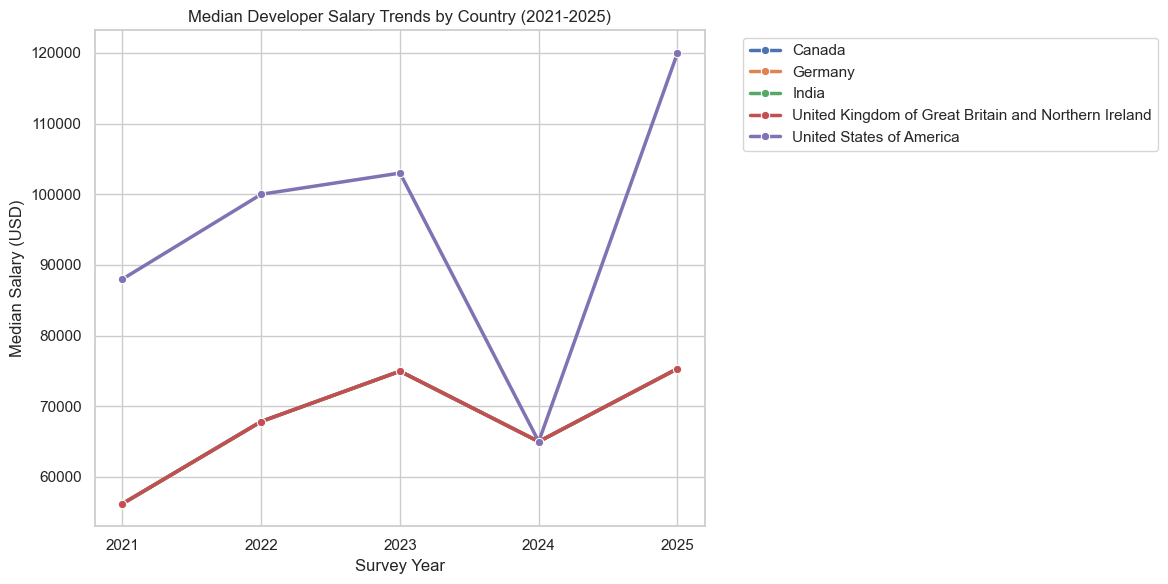

In [2]:
salary_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    d.Country,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000;
"""
df_salary = db.read_query(salary_query)

if df_salary is not None and not df_salary.empty:
    top_countries = ['United States of America', 'India', 'United Kingdom of Great Britain and Northern Ireland', 'Germany', 'Canada']
    df_top_salary = df_salary[df_salary['Country'].isin(top_countries)]
    
    median_salaries = df_top_salary.groupby(['Year', 'Country'])['ConvertedCompYearly'].median().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=median_salaries, x='Year', y='ConvertedCompYearly', hue='Country', marker='o', linewidth=2.5)
    plt.title('Median Developer Salary Trends by Country (2021-2025)')
    plt.xlabel('Survey Year')
    plt.ylabel('Median Salary (USD)')
    plt.xticks([2021, 2022, 2023, 2024, 2025])
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_trends.png'), dpi=300)
    plt.show()
else:
    print("No salary data retrieved.")

### 2. Salary vs. Professional Experience

Let's see how professional coding experience translates to compensation in 2025.

In [3]:
exp_sal_query = """
SELECT 
    f.YearsCodePro,
    d.Country,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Demographics d ON f.Dim_DemographicsID = d.Dim_DemographicsID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE YEAR(f.SurveyYear) = 2025
  AND c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND f.YearsCodePro IS NOT NULL
  AND d.Country IN ('United States of America', 'India', 'United Kingdom of Great Britain and Northern Ireland');
"""
df_exp_sal = db.read_query(exp_sal_query)

if df_exp_sal is not None and not df_exp_sal.empty:
    def bucket_exp(exp):
        try:
            val = int(exp)
            if val < 2: return '0-1 years'
            elif val < 5: return '2-4 years'
            elif val < 10: return '5-9 years'
            elif val < 15: return '10-14 years'
            else: return '15+ years'
        except:
            return 'Unknown'
            
    df_exp_sal['Experience_Group'] = df_exp_sal['YearsCodePro'].apply(bucket_exp)
    df_exp_sal = df_exp_sal[df_exp_sal['Experience_Group'] != 'Unknown']
    order = ['0-1 years', '2-4 years', '5-9 years', '10-14 years', '15+ years']
    
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_exp_sal, x='Experience_Group', y='ConvertedCompYearly', hue='Country', order=order, palette='Set2')
    plt.title('Developer Salaries by Professional Experience and Country (2025)')
    plt.xlabel('Professional Experience')
    plt.ylabel('Salary (USD)')
    plt.legend(title='Country')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_experience.png'), dpi=300)
    plt.show()
else:
    print("No experience/salary data available.")

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully
No experience/salary data available.


### 3. Salary vs. Education Level

Does higher education lead to higher median compensation?

In [ ]:
edu_sal_query = """
SELECT 
    edu.Education_Level,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Education edu ON f.Dim_EducationID = edu.Dim_EducationID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE YEAR(f.SurveyYear) = 2025
  AND c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND edu.Education_Level IS NOT NULL AND edu.Education_Level <> 'Unknown';
"""
df_edu_sal = db.read_query(edu_sal_query)

if df_edu_sal is not None and not df_edu_sal.empty:
    # Calculate medians
    median_edu = df_edu_sal.groupby('Education_Level')['ConvertedCompYearly'].median().reset_index().sort_values(by='ConvertedCompYearly', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=median_edu, x='ConvertedCompYearly', y='Education_Level', palette='coolwarm')
    plt.title('Median Developer Salary by Education Level (2025)')
    plt.xlabel('Median Salary (USD)')
    plt.ylabel('Education Level')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_education.png'), dpi=300)
    plt.show()
else:
    print("No education/salary data available.")

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


### 4. Employment Status Distribution

Let's see how developers are employed across different years.

In [ ]:
emp_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    emp.EmploymentAddl AS EmploymentStatus,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE emp.EmploymentAddl IS NOT NULL AND emp.EmploymentAddl <> 'Unknown' AND emp.EmploymentAddl <> ''
GROUP BY YEAR(f.SurveyYear), emp.EmploymentAddl;
"""
df_emp = db.read_query(emp_query)

if df_emp is not None and not df_emp.empty:
    top_statuses = df_emp.groupby('EmploymentStatus')['Count'].sum().nlargest(4).index.tolist()
    df_top_emp = df_emp[df_emp['EmploymentStatus'].isin(top_statuses)]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_emp, x='EmploymentStatus', y='Count', hue='Year', palette='deep')
    plt.title('Developer Employment Status Distribution (2021-2025)')
    plt.xlabel('Employment Status')
    plt.ylabel('Respondent Count')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_employment_status.png'), dpi=300)
    plt.show()
else:
    print("No employment data available.")

### 5. Salary vs. Organization Size

Does organizational scale correlate with higher compensation?

In [ ]:
org_sal_query = """
SELECT 
    emp.Organization_Size,
    c.ConvertedCompYearly
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
JOIN Snowflake.Dim_Compensation c ON f.Dim_CompensationID = c.Dim_CompensationID
WHERE YEAR(f.SurveyYear) = 2025
  AND c.ConvertedCompYearly IS NOT NULL 
  AND c.ConvertedCompYearly > 5000 
  AND c.ConvertedCompYearly < 500000
  AND emp.Organization_Size IS NOT NULL AND emp.Organization_Size <> 'Unknown' AND emp.Organization_Size <> '';
"""
df_org_sal = db.read_query(org_sal_query)

if df_org_sal is not None and not df_org_sal.empty:
    org_medians = df_org_sal.groupby('Organization_Size')['ConvertedCompYearly'].median().reset_index()
    
    # Order by size
    size_order = [
        'Just me - 1 person', 
        '2 to 9 employees', 
        '10 to 19 employees', 
        '20 to 99 employees', 
        '100 to 499 employees', 
        '500 to 999 employees', 
        '1,000 to 4,999 employees', 
        '5,000 to 9,999 employees', 
        '10,000 or more employees'
    ]
    org_medians = org_medians.set_index('Organization_Size').reindex(size_order).dropna().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=org_medians, x='ConvertedCompYearly', y='Organization_Size', palette='viridis')
    plt.title('Median Developer Salary by Organization Size (2025)')
    plt.xlabel('Median Salary (USD)')
    plt.ylabel('Organization Size')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '02_salary_by_org_size.png'), dpi=300)
    plt.show()
else:
    print("No organization/salary data available.")

In [ ]:
db.close()